# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [66]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [64]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [63]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [62]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length,duration_nulo,lenght_nulo,is_text,is_call
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,0,1,0,1
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,1,0,1,0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,1,0,1,0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN,0,1,0,1
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN,0,1,0,1


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [61]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 10)


In [60]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [59]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 250.1+ KB


In [58]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             40000 non-null  int64         
 1   user_id        40000 non-null  int64         
 2   type           40000 non-null  object        
 3   date           39950 non-null  datetime64[ns]
 4   duration       17924 non-null  float64       
 5   length         22104 non-null  float64       
 6   duration_nulo  40000 non-null  int64         
 7   lenght_nulo    40000 non-null  int64         
 8   is_text        40000 non-null  int64         
 9   is_call        40000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(1)
memory usage: 3.1+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [57]:
# cantidad de nulos para users
print(users.isnull().sum()) # Cantidad de valores nulos)
print(users.isnull().mean().round(4) * 100)# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date        40
plan             0
churn_date    3534
dtype: int64
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          14.12
reg_date       1.00
plan           0.00
churn_date    88.35
dtype: float64


In [56]:
# cantidad de nulos para usage
print(usage.isnull().sum())

id                   0
user_id              0
type                 0
date                50
duration         22076
length           17896
duration_nulo        0
lenght_nulo          0
is_text              0
is_call              0
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

# comentario Adriana Diaz

En las columnas de la información de users, podemos observar que las columnas City y Churn _date presentan nulos, abarcando una cantidad de 469 nulos en la columna City representando el 11.7 % de las filas totales, en este caso debemos investigar para imputar o dejar como nulos. En la columna Churn_date se  presentan 3534 nulos de 4000 filas representando el 88.3 % de las filas totales, impulsandonos así a tomar la decision de ignorarlos o eliminarlos.

Por otro lado encontramos que la información de usage, presenta tres columnas con nulos en el primer caso esta la columna date la cual presenta 50 datos nulos de 40000 representando el 0,001 % del porcentaje total, en este caso poodremos dejar como nulos o realizar una imputación. Por otro lado esta la columna duratión con 22076 datos nulos de 40000, respresentando el 55,1% de estos, en este caso debemos investigar para saber si debemos imputar o dejar los nulos.Y por ultimo encontramos a la columna lenght en la cual encontramos 17896 datos nulos, representando el 44,7 %, en este caso como la columna anterior, debemos investigar para saber si debemos imputar o dejar los nulos



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [55]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Podemos observar que los datos estan en un rango especifico, a simple vista no se observa ninguna anomalia.
- La columna `age` por otro lado, observamos que tiene un valor de -999 en minimo esto nos muestra que presentamos sentinels de reemplazo por nulos.

In [54]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length,duration_nulo,lenght_nulo,is_text,is_call
count,40000.00000,40000.000000,17924.000000,22104.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,20000.50000,12002.405975,5.202237,52.127398,0.551900,0.447400,0.552300,0.447700
std,11547.14972,1157.279564,6.842701,56.611183,0.497305,0.497232,0.497263,0.497263
min,1.00000,10000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000,0.000000,0.000000,0.000000,0.000000
50%,20000.50000,12013.000000,3.500000,50.000000,1.000000,0.000000,1.000000,0.000000
75%,30000.25000,13005.000000,6.990000,64.000000,1.000000,1.000000,1.000000,1.000000
max,40000.00000,13999.000000,120.000000,1490.000000,1.000000,1.000000,1.000000,1.000000


- Las columnas `id` y `user_id` seven a simple vista sin niguna anomalia, con datos que al parecer estan en el rango especifico.
- Las columnas duration presenta en valor minimo 0 que al parecer puede deberse a un sentinel, aducional presenta 22076 valores nulos en toda la columna representando el 55.1 % y la columna length al igual que duration presenta en valor minimo 0 que al parecer puede deberse a un sentinel y tambireen presenta valores nulos en total 17896 representando el 44,7 %.

In [53]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

          city    plan
count     3435    4000
unique       6       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` presenta 469 datos nulos, 7 categorias en donde Bogotá es la que mas se repite con una fecuencia de 808 veces.
- La columna `plan` no presenta nulos, 2 categorias en donde Básico es la que mas frecuencia tiene con un total de 2595 veces. 

In [52]:

# explorar columna categórica de usage
usage['type']
      
# completa el código


0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object

- La columna `type` podemos observar que se presentan nulos en algunas filas, y observamos que tenemos 2 valores en esta columna, ya sea Call o text.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [50]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [51]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [46]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

En `reg_date`, observamos un error muy notorio y es que presenta datos del año 2026, pero en nuestra información solo tenemos hasta el año 2024, alertandonos asi a investigar porque presentanos esos datos erroneos

In [47]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`,en cambio solo observamos fechas del 2024 y 50 datos nulos, mostrandonos que no tenemos datos para comparar con la informacion de users de esos años anteriores.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [45]:

# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
users['age'] = users['age'].fillna(users['age'].median())

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [44]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)



# Verificar cambios
print(users['city'].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [43]:
# Marcar fechas futuras como NA para reg_date

fecha_max = pd.Timestamp('2024-12-31')

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

users.loc[users['reg_date'] > fecha_max, 'reg_date'] = pd.NaT


# Verificar cambios
print(users['reg_date'].isnull().sum())
print(users['reg_date'].dt.year.value_counts().sort_index())


40
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [42]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_nulo'] = usage['duration'].isnull().astype(int)
print(usage.groupby('type')['duration_nulo'].mean().round(2) * 100)

type
call      0.0
text    100.0
Name: duration_nulo, dtype: float64


In [41]:
# Verificación MAR en usage (Missing At Random) para length
usage['lenght_nulo'] = usage['length'].isnull().astype(int)
print(usage.groupby('type')['lenght_nulo'].mean().round(2) * 100)

type
call    100.0
text      0.0
Name: lenght_nulo, dtype: float64


En las columnas `duration` y `length`presentan nulos MNAR (Missing Not At Random), esto quiere decir que son correctos, en ese orden de ideas no los eliminaremos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [40]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes        = ("is_text",   "sum"),
    cant_llamadas        = ("is_call",   "sum"),
    cant_minutos_llamada = ("duration",  "sum")
).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'cant_mensajes':        'cant_mensajes',
    'cant_llamadas':        'cant_llamadas',
    'cant_minutos_llamada': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [37]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

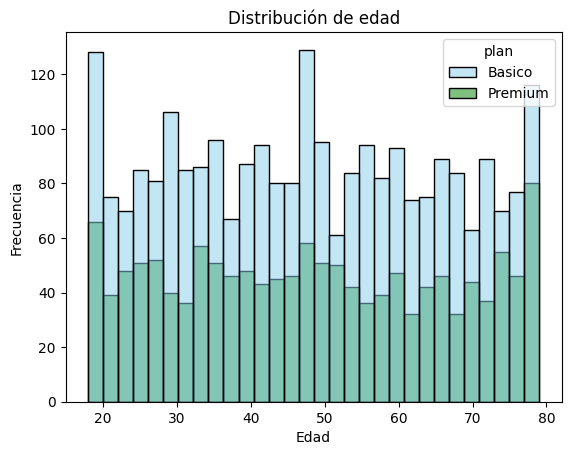

In [68]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data     = user_profile,
    x        = 'age',
    hue      = 'plan',
    bins     = 30,
    palette  = ['skyblue', 'green'],
    edgecolor= 'black'
)
plt.title('Distribución de edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de edad es simétrica 
- Los usuarios del plan Premium se concentran entre los 20 y 80 años.
- Los usuarios del plan Básico tienden a estar sobre los adultos de 50 años.
- No existe una diferencia clara entre planes respecto a la edad.

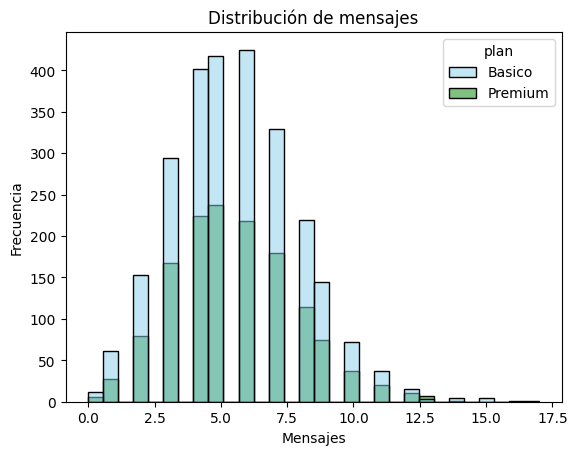

In [69]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data     = user_profile,
    x        = 'cant_mensajes',
    hue      = 'plan',
    bins     = 30,
    palette  = ['skyblue', 'green'],
    edgecolor= 'black'
)
plt.title('Distribución de mensajes')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Está sesgada a la derecha, 
la mayoría de usuarios se concentra entre 0 y 10 mensajes, con una cola larga hacia valores altos.
El pico está alrededor de 5-6 mensajes, que representa el comportamiento más común.


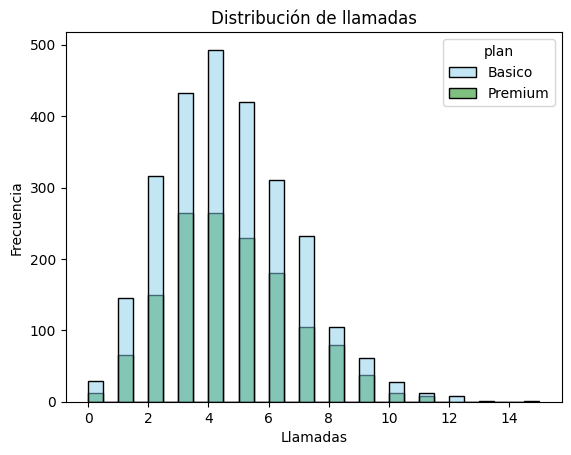

In [70]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data     = user_profile,
    x        = 'cant_llamadas',
    hue      = 'plan',
    bins     = 30,
    palette  = ['skyblue', 'green'],
    edgecolor= 'black'
)
plt.title('Distribución de llamadas')
plt.xlabel('Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Esta sesgada a la derecha con mas usuarios entre 2 y 6 llamadas, con un pico sobre 4 llamadas.

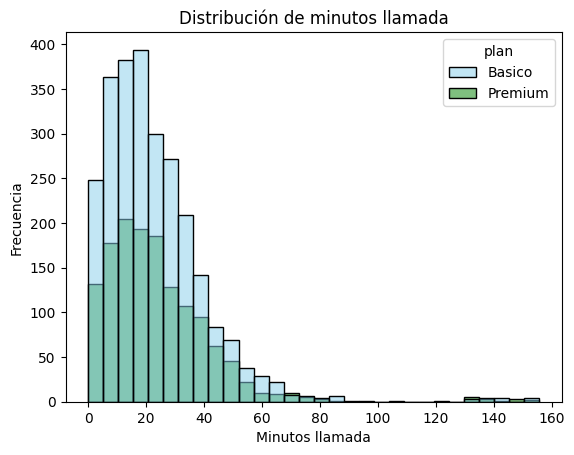

In [72]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data     = user_profile,
    x        = 'cant_minutos_llamada',
    hue      = 'plan',
    bins     = 30,
    palette  = ['skyblue', 'green'],
    edgecolor= 'black'
)
plt.title('Distribución de minutos llamada')
plt.xlabel('Minutos llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Descripción: Esta sesgada a la derecha con  usuarios concentrados entre 0 y 40 minutos de llamada,extendiendose hasta el rango de 160 minutos llamada, que puede deberse a un outliers o a pocos usuarios de alto consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

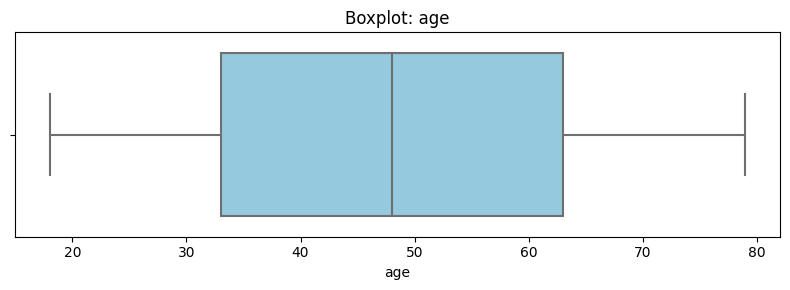

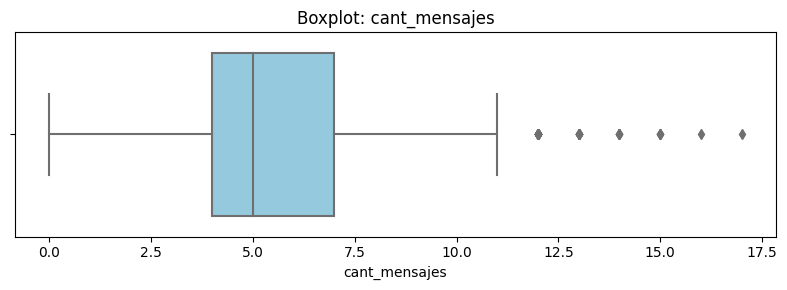

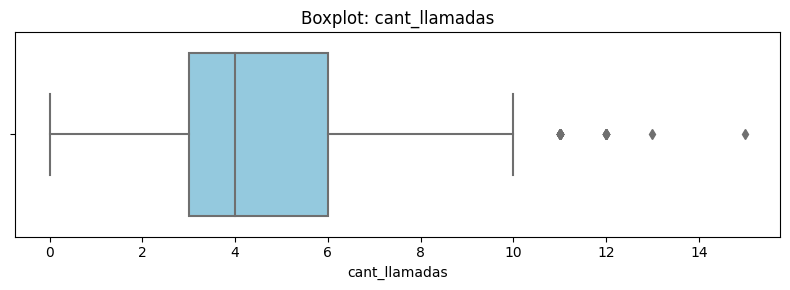

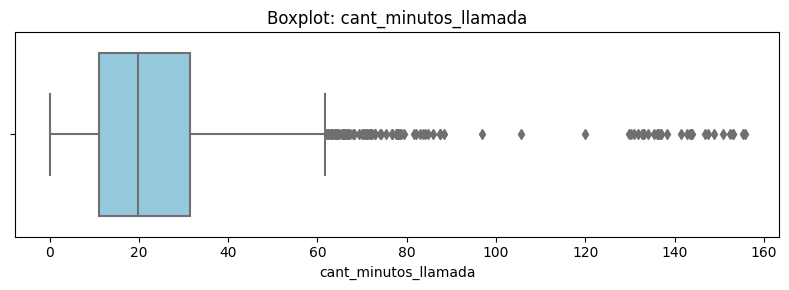

In [76]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(
        data    = user_profile,
        x       = col,
        palette = ['skyblue']
    )
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

💡Insights: 
- Age: No presenta outliers, no los observamos fuera de los bigotes 
- cant_mensajes:Presenta outliers sobrepasando los bigotes concentrandose desde el rango 11 a 17,5.
- cant_llamadas: Se presentan outliers concentrandose en el rango de 11 a 15.
- cant_minutos_llamada: Se presentan outliers densos en el rango de 61 a 90,unos pocos de 98 a 120 y otro grupo denso en el rango de 130 a 160.

In [77]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1  = user_profile[col].quantile(0.25)
    Q3  = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\n=== {col} ===")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Outliers: {(user_profile[col] > limite_superior).sum()}")






=== cant_mensajes ===
Límite superior: 11.50
Outliers: 46

=== cant_llamadas ===
Límite superior: 10.50
Outliers: 30

=== cant_minutos_llamada ===
Límite superior: 61.86
Outliers: 109


In [78]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes:Se pueden mantener los outliers ya que solo abarca un 1.15 % de nulos, esto no nos afectara la información ya que muy probablemente sean datos reales de usuarios premium.
- cant_llamadas: Se pueden mantener los outliers ya que solo abarca un 0.75 % de nulos, esto no nos afectara la información ya que muy probablemente sean datos reales de usuarios premium.
- cant_minutos_llamada: Se pueden mantener los outliers ya que solo abarca un 2.72 % de nulos, esto no nos afectara la información ya que muy probablemente sean datos reales de usuarios premium.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [79]:
# Crear columna grupo_uso
bajo  = (user_profile['cant_llamadas'] < 5)  & (user_profile['cant_mensajes'] < 5)
medio = (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)

user_profile['grupo_uso'] = 'Alto uso'
user_profile.loc[medio, 'grupo_uso'] = 'Uso medio'
user_profile.loc[bajo,  'grupo_uso'] = 'Bajo uso'


print(user_profile['grupo_uso'].value_counts())
print(user_profile['grupo_uso'].value_counts(normalize=True).mul(100).round(2))


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64
Uso medio    73.58
Bajo uso     19.45
Alto uso      6.98
Name: grupo_uso, dtype: float64


In [80]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [83]:
# Crear columna grupo_edad
Joven  = (user_profile['age'] < 30)  
Adulto = (user_profile['age'] < 60) 

user_profile['grupo_edad'] = 'Adulto Mayor'
user_profile.loc[Joven, 'grupo_edad'] = 'Joven'
user_profile.loc[Adulto,  'grupo_edad'] = 'Adulto'


print(user_profile['grupo_edad'].value_counts())
print(user_profile['grupo_edad'].value_counts(normalize=True).mul(100).round(2))

Adulto          2778
Adulto Mayor    1222
Name: grupo_edad, dtype: int64
Adulto          69.45
Adulto Mayor    30.55
Name: grupo_edad, dtype: float64


In [84]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

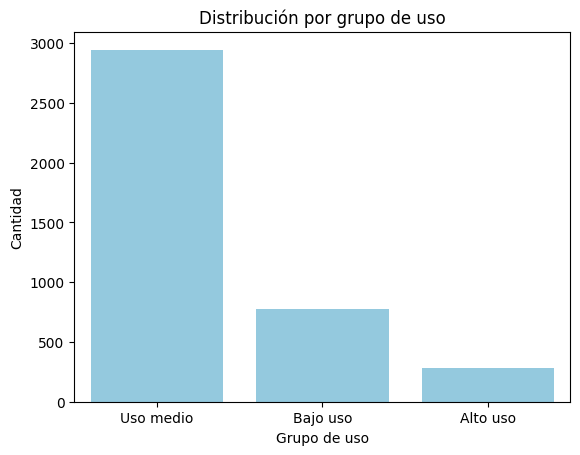

In [85]:
# Visualización de los segmentos por uso
sns.countplot(
    data  = user_profile,
    x     = 'grupo_uso',
    order = user_profile['grupo_uso'].value_counts().index,
    palette = ['skyblue']
)
plt.title('Distribución por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad')
plt.show()


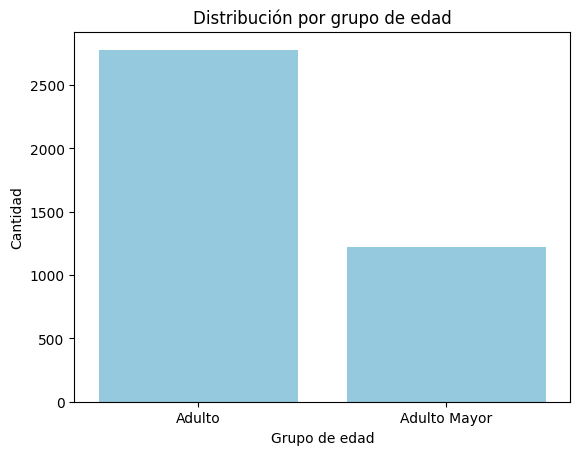

In [86]:
# Visualización de los segmentos por edad
sns.countplot(
    data  = user_profile,
    x     = 'grupo_edad',
    order = user_profile['grupo_edad'].value_counts().index,
    palette = ['skyblue']
)
plt.title('Distribución por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

En las columnas de la información de users, se presentaron datos faltantes o nulos en  las columnas City con 469 nulos representando el 11.7 % de las filas totales, en este caso debemos investigar para imputar o dejar como nulos Churn _date se presentan 3534 nulos de 4000 filas representando el 88.3 % de las filas totales En  impulsandonos así a tomar la decision de ignorarlos o eliminarlos.

Por otro lado encontramos que la información de usage, presenta tres columnas con nulos en el primer caso esta la columna date la cual presenta 50 datos nulos de 40000 representando el 0,001 % del porcentaje total, en este caso poodremos dejar como nulos o realizar una imputación. Por otro lado esta la columna duratión con 22076 datos nulos de 40000, respresentando el 55,1% de estos, en este caso debemos investigar para saber si debemos imputar o dejar los nulos.Y por ultimo encontramos a la columna lenght en la cual encontramos 17896 datos nulos, representando el 44,7 %, en este caso como la columna anterior, debemos investigar para saber si debemos imputar o dejar los nulos.

Adicional encontramos fechas fuera de los rangos, tipografia erronea de columnas que representaban fechas las cuales las cambiamos a tipo fecha.

Se puede observar que los adultos son los que mas tienen participacion en este caso, y el grupo de uso es el uso medio.

El uso medio, ya que en este se presenta mayor participacion por parte de los usuarios.

se presentaron valores nulos en 3 columnas especificas en donde cant_mensajes: presentaba 46 outliers que solo abarca un 1.15 % de nulos,cant_llamadas: presentaba 30 outliers que solo abarca un 0.75 % de nulos, 
cant_minutos_llamada:Presentaba 109 outliers que solo abarca un 2.72 % de nulos, esto no nos afectara la información ya que no supera el 5% de los datos y muy probablemente sean datos reales de usuarios premium.

Depuración de datos
   → Implementar validaciones en el registro de usuarios para 
     evitar sentinels como -999 o "?" en futuras capturas.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Nulos en diferentes columnas de users y usage
- Fecha fuera del rango especifico(2024)


🔍 **Segmentos por Edad**
- 'Joven' edad < 30

- 'Adulto' edad < 60

- 'Adulto Mayor' >60



📊 **Segmentos por Nivel de Uso**

- 'Bajo uso'  llamadas < 5 y mensajes < 5

- 'Uso medio'  llamadas < 10 y mensajes < 10

- 'Alto uso'  llamadas > 10 y mensajes > 10



➡️ Esto sugiere que hay que rediseñar la oferta de los planes actuales para lograr una cobertura mas amplia a nivel de edades, llegar a cada rincon con ofertas apetecibles y accequibles para todos.


💡 **Recomendaciones**

Establecer validaciones en el sistema de registro para evitar sentinels como -999 o "?" en futuras capturas de datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`